In [14]:
import glob
import os.path as osp
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import rel_entr
from scipy.stats import gaussian_kde, ks_2samp, chi2
from scipy.integrate import cumulative_trapezoid
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.dpi"] = 100
#np.set_printoptions(suppress=True, precision=4)


In [15]:
RUN_TYPE = 'sampling'
RESULTS_ROOT = osp.abspath(osp.join("..", "data", "results_mp_sampling"))
MODEL_NAME = "gpt4o_mini" # All or specific model name
_KNOWN_DATASETS = sorted(
    ["arc_c", "arc_e", "csqa", "obqa", "race", "sciq"], key=len, reverse=True
)
SEED = None
DATASET = "obqa"  # All or specific dataset name
OUTPUT_FILE_NAME = 'martingale_sampling_results.npz'

In [16]:
def parse_run_folder(folder_name: str):
    """Split '<dataset>_<model>' into (dataset, model) using known dataset codes."""
    for ds in _KNOWN_DATASETS:
        prefix = ds + "_"
        if folder_name.startswith(prefix):
            return ds, folder_name[len(prefix):]
    return folder_name, "unknown"

all_run_dirs = sorted(glob.glob(osp.join(RESULTS_ROOT, "*")))

registry_rows = []
for run_dir in all_run_dirs:
    folder = osp.basename(run_dir)
    dataset, model = parse_run_folder(folder)
    npz_path = osp.join(run_dir, "martingale_check", RUN_TYPE, OUTPUT_FILE_NAME)
    registry_rows.append({
        "folder": folder,
        "dataset": dataset,
        "model": model,
        "npz_path": npz_path,
        "available": osp.exists(npz_path),
    })

registry = pd.DataFrame(registry_rows)

if MODEL_NAME != "all":
    registry = registry[registry["model"] == MODEL_NAME]

display(registry)


missing = registry.loc[~registry["available"], "folder"].tolist()
if missing:
    print(f"Skipping {len(missing)} incomplete run(s) (no martingale_results.npz found): {missing}")

registry = registry[registry["available"]].reset_index(drop=True)
print(f"\n{len(registry)} completed run(s) available for testing.")


,folder,dataset,model,npz_path,available
0,obqa_gpt4o_mini,obqa,gpt4o_mini,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True



1 completed run(s) available for testing.


In [17]:
def normalize_distributions(d: np.ndarray) -> np.ndarray:
    """Coerce to (Q, J, K+1, C). (K+1,C)->(1,1,K+1,C); (Q,K+1,C)->(Q,1,K+1,C)."""
    if d.ndim == 2:
        d = d[np.newaxis, np.newaxis, :]
    elif d.ndim == 3:
        d = d[:, np.newaxis, :]
    return d


def load_run(npz_path: str, seed: str = None) -> dict:
    """Load one seed's results dict from a martingale_results.npz file."""
    if seed:
        raw = np.load(npz_path, allow_pickle=True)
        seed = seed or list(raw.keys())[0]
        dat = raw[seed].item()
    else:
        with np.load(npz_path, allow_pickle=True) as raw:
            dat = {key: raw[key] for key in raw.files}
            if "metadata" in dat:
                dat["metadata"] = dat["metadata"].item()

    dat["distributions"] = normalize_distributions(np.asarray(dat["distributions"], dtype=np.float64))
    return dat


# Sanity-check the loader on the first available run
_example = load_run(registry.loc[0, "npz_path"], seed=SEED)
Q, J, Kp1, C = _example["distributions"].shape
print(f"Example run: {registry.loc[0, 'folder']}")
print(f"  distributions shape: (Q={Q} questions, J={J} trajectories, K+1={Kp1} steps, C={C} classes)")
print(f"  keys: {list(_example.keys())}")

Example run: obqa_gpt4o_mini
  distributions shape: (Q=2 questions, J=5 trajectories, K+1=50 steps, C=4 classes)
  keys: ['logits', 'probs', 'distributions', 'labels', 'label_history', 'branch_logits', 'branch_probs', 'expected_next', 'residuals', 'error_l1', 'error_l2', 'error_max', 'centered_logits', 'entropy', 'js_from_initial', 'true_labels', 'input_texts', 'data_indices', 'selected_dataset_indices', 'trajectory_seeds', 'prompt_history', 'branch_prompt_history', 'metadata']


In [18]:
overview_rows = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    Q, J, Kp1, C = dat["distributions"].shape
    overview_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "N_questions": Q,
        "J_trajectories": J,
        "K_steps": Kp1 - 1,
        "C_classes": C,
        "accuracy_at_p0": float(dat["accuracy_at_p0"]),
        "mean_tv": float(dat["mean_tv"]),
        "pass_rate_tv_0.05": float(dat["pass_rate_tv_005"]),
        "pass_rate_tv_0.10": float(dat["pass_rate_tv_010"]),
        "mean_l1": float(dat["mean_l1"]),
    })

overview = pd.DataFrame(overview_rows).sort_values("mean_tv").reset_index(drop=True)
overview.style.format({
    "accuracy_at_p0": "{:.3f}", "mean_tv": "{:.4f}", "pass_rate_tv_0.05": "{:.3f}",
    "pass_rate_tv_0.10": "{:.3f}", "mean_l1": "{:.4f}",
}).background_gradient(subset=["mean_tv"], cmap="Reds")


KeyError: 'accuracy_at_p0'

In [21]:
EPS = 1e-9

def to_clr(p: np.ndarray) -> np.ndarray:
    """Centered log-ratio transform: maps the simplex to unconstrained R^C."""
    p = np.clip(p, EPS, 1)
    log_p = np.log(p)
    return log_p - log_p.mean(axis=-1, keepdims=True)

In [22]:
DATASET_KEY = DATASET + '_' + MODEL_NAME
DATA_PATH = registry.loc[registry["folder"].str.lower().str.contains(DATASET_KEY.lower()), "npz_path"].values[0]
dat = load_run(DATA_PATH, seed=SEED)

In [23]:
p_all = dat["distributions"]  # (Q, J, K+1, C)
logits_all = to_clr(p_all)

### 1) Qualitative Analysis

In [24]:
def plot_class_trajectories(p_all_deep: np.ndarray, dataset_key: str,
                             log_scale: bool = False) -> None:
    """p_all_deep: (Q, K+1, C) -- J-averaged distributions. One line per class,
    x-axis = step index.

    log_scale=False (default): plain [0, 1] probability axis.
    log_scale=True: log-scale y-axis. Matters most when Q is small (e.g. a
    single question) -- probabilities near 0 or 1 are visually indistinguishable
    on a linear axis (0.999998 and 0.9999999874 both just look like "1"), the
    same compression problem the CLR-space CDF plot above is built to avoid.
    A log y-axis fixes this directly for a single class's own trajectory,
    without needing the full CLR machinery.
    """
    p_all_deep = p_all_deep.mean(axis=1)  # (Q, K+1, C)
    Q, K, C = p_all_deep.shape
    #dat_q = p_all_deep[q]  # (K+1, C)
    x = np.arange(1, K + 1)

    for q in range(Q):
        dat_q = p_all_deep[q]  # (K+1, C)
        fig, ax = plt.subplots(figsize=(12, 5))
        for c in range(C):
            y = dat_q[:, c]
            if log_scale:
                y = np.clip(y, 1e-12, 1.0)  # guard against exact 0 on a log axis
            ax.plot(x, y, marker='o', markersize=4, label=f"Class {c}")

        ax.set_xlabel("Step index")
        ax.set_ylabel("Probability" + (" (log scale)" if log_scale else ""))
        if log_scale:
            ax.set_yscale('log')
        ax.set_title(
            f"Class probability trajectories — {dataset_key}, question {q}"
            + (" [log scale]" if log_scale else "")
        )
        if K <= 40:
            ax.set_xticks(x)
        ax.legend()
        ax.grid(True, alpha=0.3, which='both' if log_scale else 'major')
        plt.tight_layout()
        plt.show()

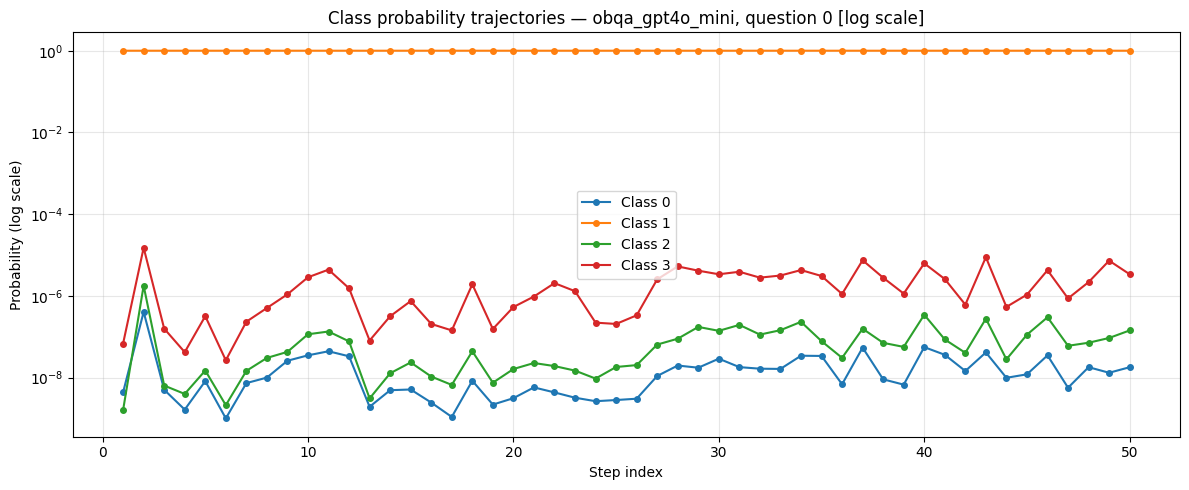

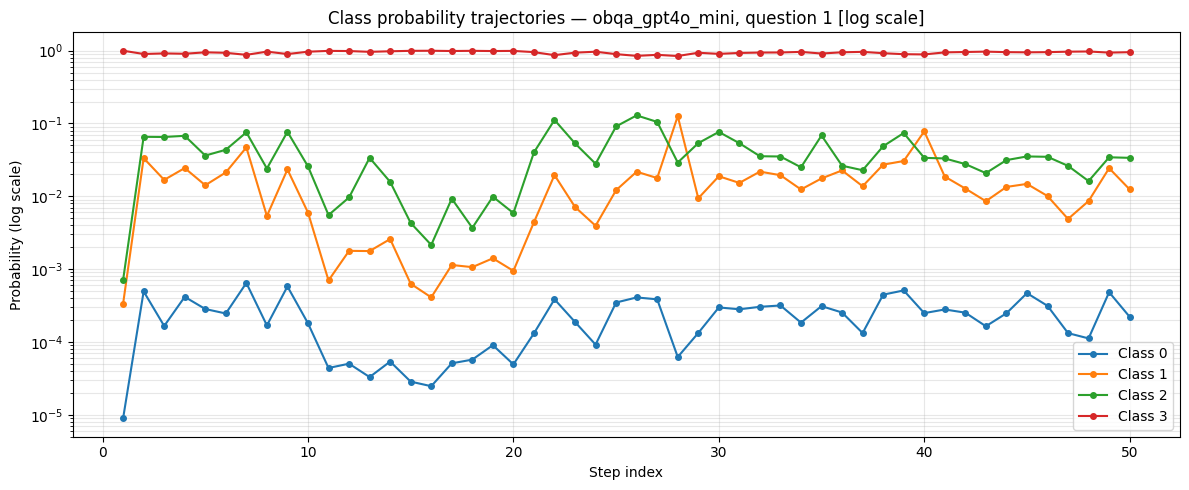

In [25]:
plot_class_trajectories(p_all, DATASET_KEY, log_scale=True)

In [26]:
def divergence_from_prior_trajectory(p_all: np.ndarray, dataset_key: str, logits = False) -> None:

    p_all_cum_deep = p_all.mean(axis=1)  # (Q, K+1, C), J-averaged
    Q_cum, Kp1_cum, C_cum = p_all_cum_deep.shape

    if logits:
        p_all_cum_deep = p_all_cum_deep - p_all_cum_deep.mean(axis=-1, keepdims=True)  # Centered log-ratio transform
    
    for q in range(Q_cum):
        theta_q = p_all_cum_deep[q]                        # (K+1, C)
        theta_first = theta_q[0]                            # theta_0 -- the first step
        cum_diff_q = theta_q[1:] - theta_first[None, :]      # (K, C): theta_k - theta_0, k=1..K
        k_axis = np.arange(1, Kp1_cum)

        fig, ax = plt.subplots(figsize=(12, 5))
        for c in range(C_cum):
            line, = ax.plot(k_axis, cum_diff_q[:, c], marker='o', markersize=4, label=f"Class {c}")
            mean_c = cum_diff_q[:, c].mean()
            ax.axhline(mean_c, color=line.get_color(), linestyle="--", linewidth=1.5, alpha=0.8,
                    label=f"Class {c} mean={mean_c:.2e}")

        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_xlabel("Step k")
        ax.set_ylabel(r"$\theta_k - \theta_0$")
        ax.set_title(f"Difference from first step (θ_0) — {dataset_key}, question {q}")
        if Kp1_cum <= 40:
            ax.set_xticks(k_axis)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [76]:
p_all.shape

(2, 5, 50, 4)

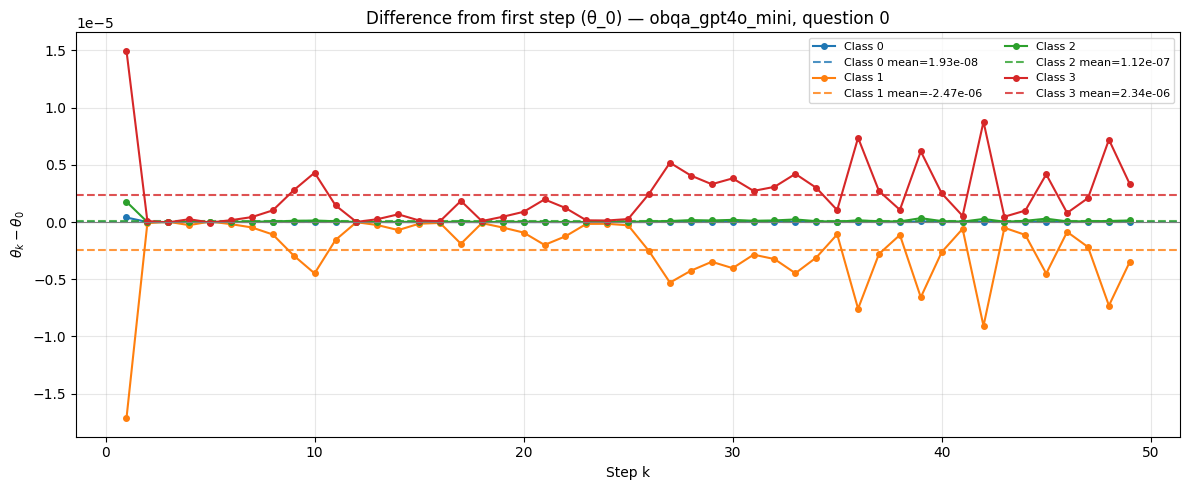

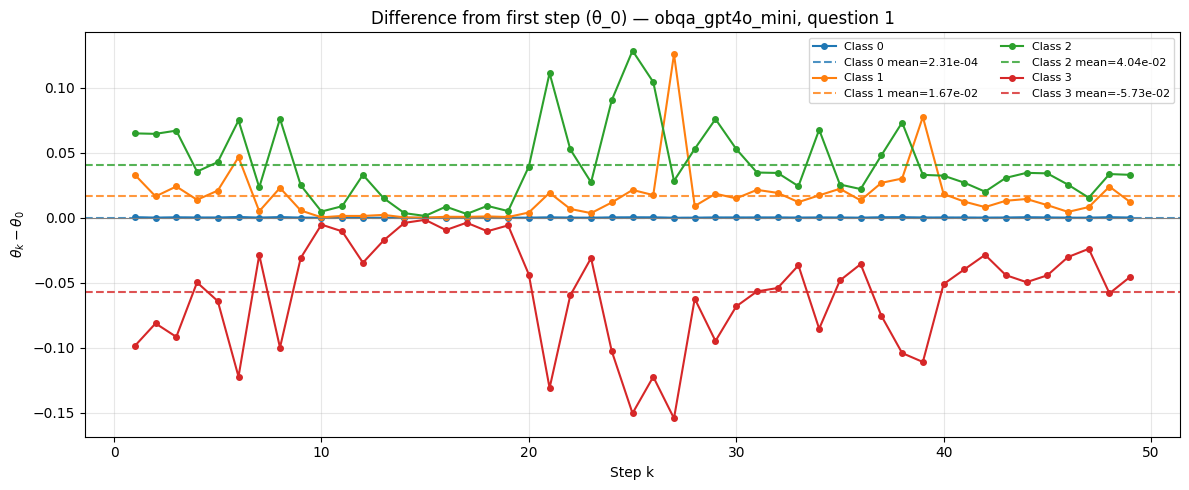

In [78]:
divergence_from_prior_trajectory(p_all, DATASET_KEY)

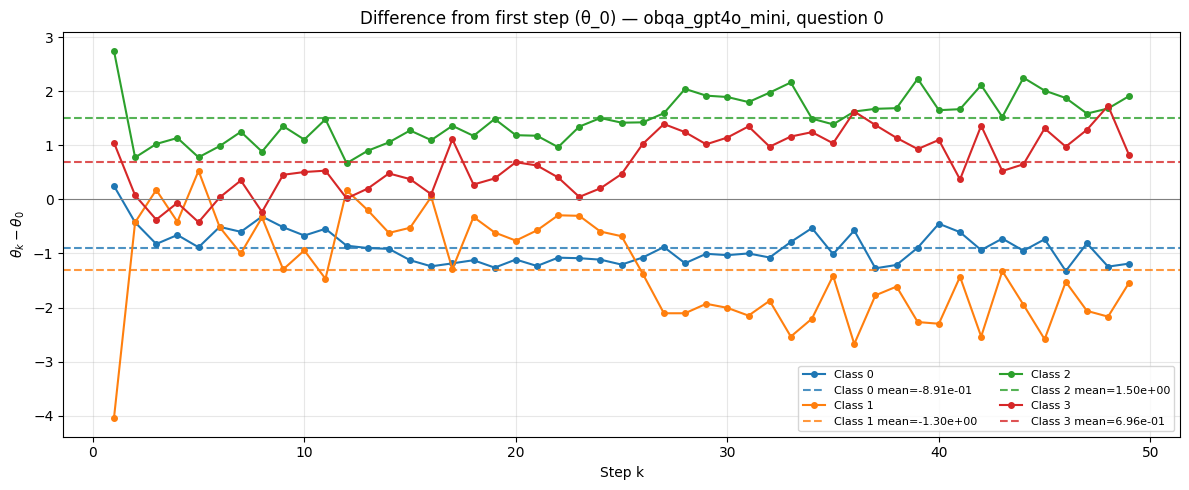

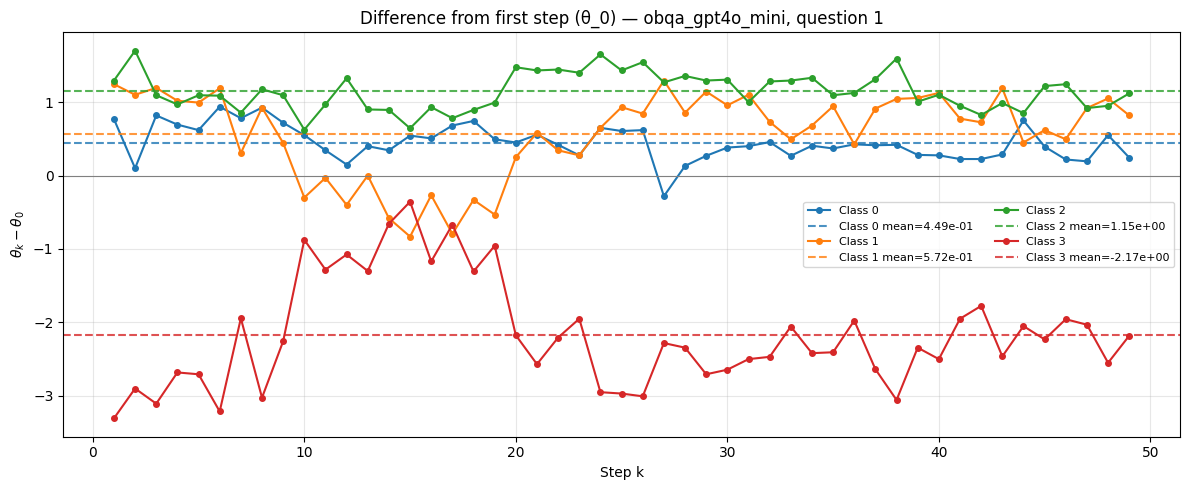

In [28]:
divergence_from_prior_trajectory(logits_all, dataset_key=DATASET_KEY, logits=True)

### 2) Quantitative Analysıs

In [29]:
def drift_from_prior(p_all: np.ndarray, dataset_key: str, logits: bool = False,
                      class_labels=None, sigma: float = 1.0) -> None:
    """Per-question, per-step drift summary built directly from the J
    trajectories, without collapsing over K into a single number per
    trajectory (contrast divergence_from_prior_trajectory, which averages
    over J first; and the earlier version of this function, which further
    collapsed over K). For every step k=1..K, computes the mean and sd of
    (theta_k[j] - theta_0[j]) across the J trajectories, and reports
    mean +- sigma*sd at that step -- so every step's value is visible as its
    own column, only J is ever reduced (to a mean/sd), never K.

    For each question, also prints a quick per-class summary of how many
    steps have a mean +- sigma*sd band that excludes 0 (i.e. drift looks
    consistently one-sided at that step, not just noise around 0), plus the
    exact step numbers where that happens.
    """
    p = p_all
    Q, J, Kp1, C = p.shape
    K = Kp1 - 1
    class_labels = class_labels or [chr(65 + c) for c in range(C)]

    if logits:
        p = to_clr(p)

    theta_0 = p[:, :, 0:1, :]                  # (Q, J, 1, C)
    step_diff = p[:, :, 1:, :] - theta_0        # (Q, J, K, C): theta_k - theta_0 per trajectory, every step
    step_indices = np.arange(1, K + 1)

    for q in range(Q):
        mean_kc = step_diff[q].mean(axis=0)       # (K, C): mean over J trajectories, per step
        sd_kc = step_diff[q].std(axis=0, ddof=1)  # (K, C): sd over J trajectories, per step
        lower_kc = mean_kc - sigma * sd_kc
        upper_kc = mean_kc + sigma * sd_kc

        print(f"=== {dataset_key}, question {q} ===")

        # Quick summary: at how many steps -- and which ones -- does the
        # mean +- sigma*sd band NOT contain 0 for each class.
        excludes_zero = (lower_kc > 0) | (upper_kc < 0)  # (K, C)
        n_excl = excludes_zero.sum(axis=0)
        zero_summary = pd.DataFrame({
            "n_steps_excl_0": n_excl,
            "pct_steps_excl_0": n_excl / K * 100,
            "steps_excl_0": [
                ", ".join(map(str, step_indices[excludes_zero[:, c]])) or "-"
                for c in range(C)
            ],
        }, index=class_labels)
        zero_summary.index.name = "class"
        print(f"Steps where mean +- {sigma}sd excludes 0 (of {K} steps):")
        display(zero_summary.style.format({"pct_steps_excl_0": "{:.1f}%"}))

        stacked = np.stack([mean_kc, lower_kc, upper_kc], axis=-1)  # (K, C, 3)
        data = stacked.transpose(1, 0, 2).reshape(C, K * 3)          # (C, K*3)
        columns = pd.MultiIndex.from_product(
            [range(1, K + 1), ["mean", f"-{sigma}sd", f"+{sigma}sd"]], names=["step", "stat"]
        )
        summary = pd.DataFrame(data, index=class_labels, columns=columns)
        summary.index.name = "class"

        vmax = float(np.abs(data).max()) or 1.0
        print(f"Per-step drift (theta_k - theta_0, mean +- {sigma}sd across J={J} trajectories):")
        display(summary.style.format("{:.4f}")
                .background_gradient(cmap='coolwarm', vmin=-vmax, vmax=vmax, axis=None))

In [30]:
drift_from_prior(p_all, DATASET_KEY, sigma = 3.0)

=== obqa_gpt4o_mini, question 0 ===
Steps where mean +- 3.0sd excludes 0 (of 49 steps):


,n_steps_excl_0,pct_steps_excl_0,steps_excl_0
class,,,
A,5,10.2%,"3, 5, 15, 16, 44"
B,1,2.0%,5
C,2,4.1%,"40, 43"
D,1,2.0%,5


Per-step drift (theta_k - theta_0, mean +- 3.0sd across J=5 trajectories):


=== obqa_gpt4o_mini, question 1 ===
Steps where mean +- 3.0sd excludes 0 (of 49 steps):


,n_steps_excl_0,pct_steps_excl_0,steps_excl_0
class,,,
A,3,6.1%,"1, 2, 3"
B,1,2.0%,2
C,2,4.1%,"1, 2"
D,3,6.1%,"1, 2, 3"


Per-step drift (theta_k - theta_0, mean +- 3.0sd across J=5 trajectories):


In [31]:
drift_from_prior(p_all, DATASET_KEY, logits=True, sigma=3.0)

=== obqa_gpt4o_mini, question 0 ===
Steps where mean +- 3.0sd excludes 0 (of 49 steps):


,n_steps_excl_0,pct_steps_excl_0,steps_excl_0
class,,,
A,23,46.9%,"3, 5, 12, 13, 14, 15, 16, 18, 19, 20, 21, 23, 24, 25, 27, 28, 30, 31, 35, 37, 44, 46, 49"
B,15,30.6%,"1, 5, 31, 33, 34, 35, 36, 38, 40, 43, 44, 45, 46, 47, 48"
C,35,71.4%,"1, 2, 3, 4, 5, 7, 11, 12, 15, 16, 17, 18, 19, 20, 21, 23, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46, 48"
D,8,16.3%,"1, 5, 31, 34, 36, 38, 45, 47"


Per-step drift (theta_k - theta_0, mean +- 3.0sd across J=5 trajectories):


=== obqa_gpt4o_mini, question 1 ===
Steps where mean +- 3.0sd excludes 0 (of 49 steps):


,n_steps_excl_0,pct_steps_excl_0,steps_excl_0
class,,,
A,7,14.3%,"1, 3, 6, 8, 9, 10, 15"
B,2,4.1%,"1, 2"
C,2,4.1%,"1, 2"
D,18,36.7%,"1, 2, 3, 4, 5, 6, 9, 20, 23, 24, 26, 28, 30, 35, 38, 40, 43, 47"


Per-step drift (theta_k - theta_0, mean +- 3.0sd across J=5 trajectories):


In [32]:
def jsd_divergence(p_all: np.ndarray, dataset_key: str) -> np.ndarray:
    """p_all: (Q, J, K+1, C). Averages over J (trajectories), then computes
    the Jensen-Shannon divergence JSD(theta_0, theta_k) for every step
    k=1..K, per question -- same JSD formula as Test 1's
    scenario_comparison_test (0.5*KL(P||M) + 0.5*KL(Q||M), M = 0.5*(P+Q)),
    just evaluated at every step instead of collapsed into one number
    against the K-step-averaged posterior.

    Plots one figure per question (JSD vs step k) and returns the (Q, K)
    array of JSD values.
    """
    p_all_deep = p_all.mean(axis=1)  # (Q, K+1, C), J-averaged
    Q, Kp1, C = p_all_deep.shape
    K = Kp1 - 1

    theta_0 = p_all_deep[:, 0, :]           # (Q, C)
    theta_k = p_all_deep[:, 1:, :]          # (Q, K, C)

    m_dist = 0.5 * (theta_0[:, None, :] + theta_k)  # (Q, K, C)
    jsd = 0.5 * (
        rel_entr(theta_0[:, None, :], np.clip(m_dist, EPS, 1)).sum(axis=-1)
        + rel_entr(theta_k, np.clip(m_dist, EPS, 1)).sum(axis=-1)
    )  # (Q, K)
    #jsd = np.clip(jsd, 0, None)  # guard tiny negative floating-point noise; JSD >= 0 always

    k_axis = np.arange(1, K + 1)
    for q in range(Q):
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(k_axis, jsd[q], marker='o', markersize=4, color="steelblue")
        ax.set_xlabel("Step k")
        ax.set_ylabel("Jensen-Shannon divergence")
        ax.set_title(f"JSD(θ_0, θ_k) per step — {dataset_key}, question {q}")
        if K <= 40:
            ax.set_xticks(k_axis)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return jsd

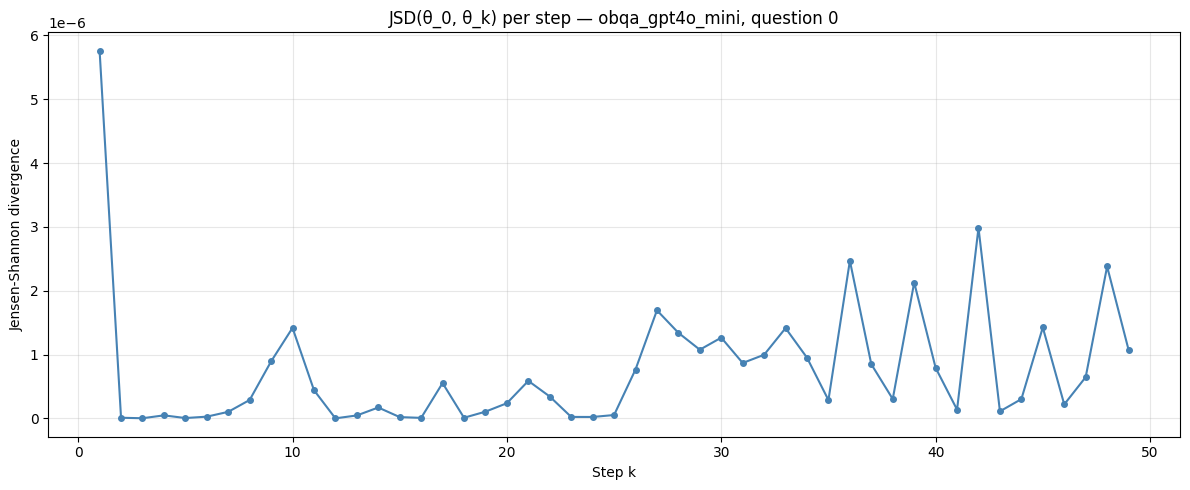

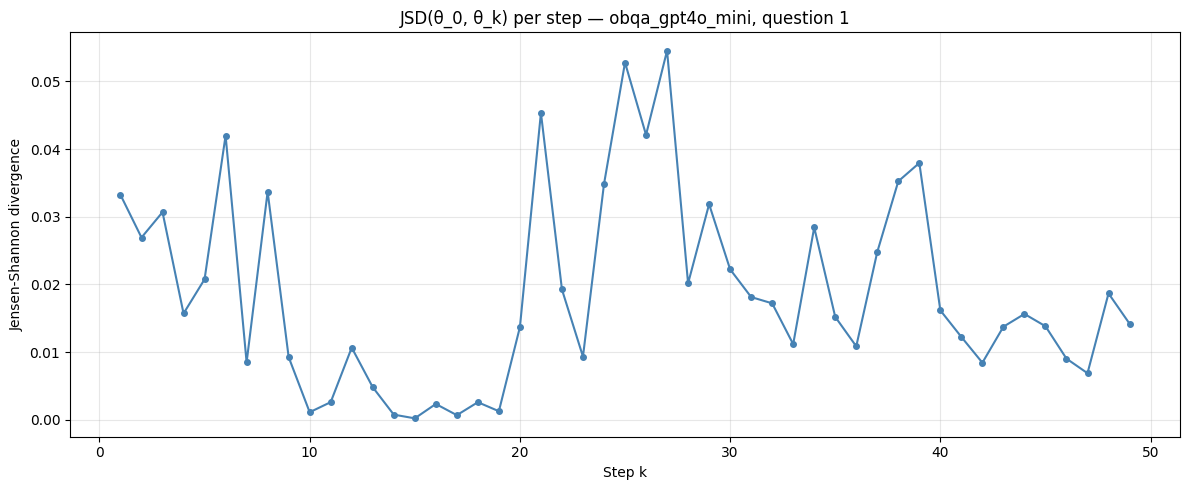

In [33]:
jsd_per_step = jsd_divergence(p_all, DATASET_KEY)

In [34]:
def entropy_assessment(p_all: np.ndarray, dataset_key: str) -> np.ndarray:
    """p_all: (Q, J, K+1, C). Averages over J (trajectories), then computes
    the Shannon entropy H(theta_k) = -sum_c theta_k[c]*log(theta_k[c]) at
    every step k=0..K, per question -- same entropy formula as Test 2's
    marginal_ks_and_entropy_test, just kept per-question here instead of
    averaged into one trend line across all questions.

    High entropy = more uniform/uncertain belief; low entropy = more
    peaked/confident (entropy -> 0 as the distribution -> one-hot). Max
    possible entropy is log(C), reached at the uniform distribution -- noted
    as a text annotation rather than an axhline, since a confident model's
    actual entropy can be orders of magnitude below log(C) (e.g. 1e-6 vs
    1.6), and an axhline there would force the y-axis to include that huge
    reference value, flattening the real per-step variation into a
    visually-flat line near 0.

    Plots one figure per question (entropy vs step k, including k=0, the
    prior), y-axis auto-scaled to the actual entropy range, and returns the
    (Q, K+1) array of entropy values.
    """
    p_all_deep = p_all.mean(axis=1)  # (Q, K+1, C), J-averaged
    Q, Kp1, C = p_all_deep.shape

    p_clip = np.clip(p_all_deep, EPS, 1)
    entropy = -(p_all_deep * np.log(p_clip)).sum(axis=-1)  # (Q, K+1)

    k_axis = np.arange(Kp1)
    for q in range(Q):
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(k_axis, entropy[q], marker='o', markersize=4, color="darkorange")
        ax.set_xlabel("Step k")
        ax.set_ylabel("Entropy H(θ_k)")
        ax.set_title(f"Entropy per step — {dataset_key}, question {q}")
        ax.text(0.99, 0.98, f"max possible = log({C}) = {np.log(C):.3f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8, color="gray")
        if Kp1 <= 40:
            ax.set_xticks(k_axis)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return entropy

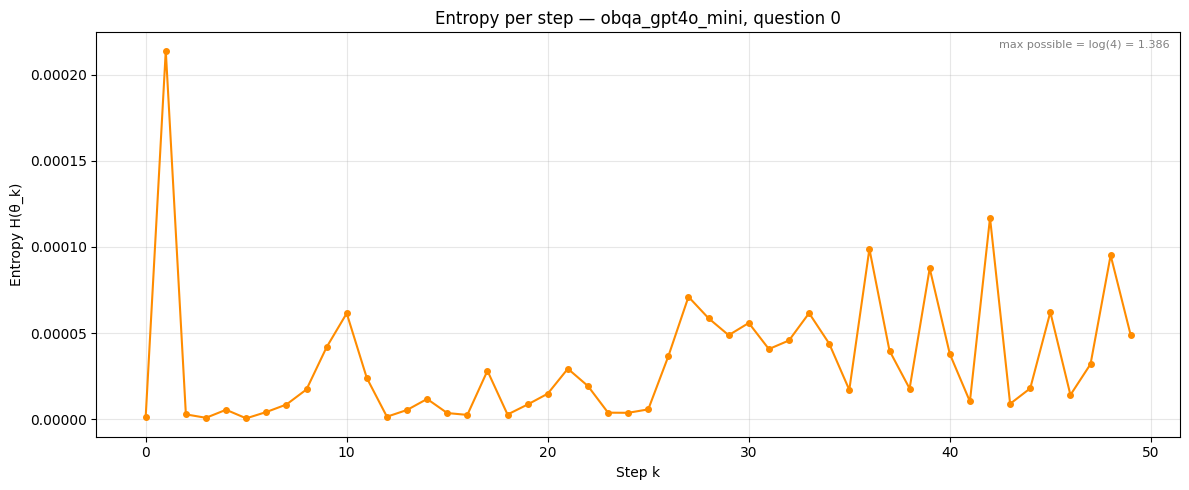

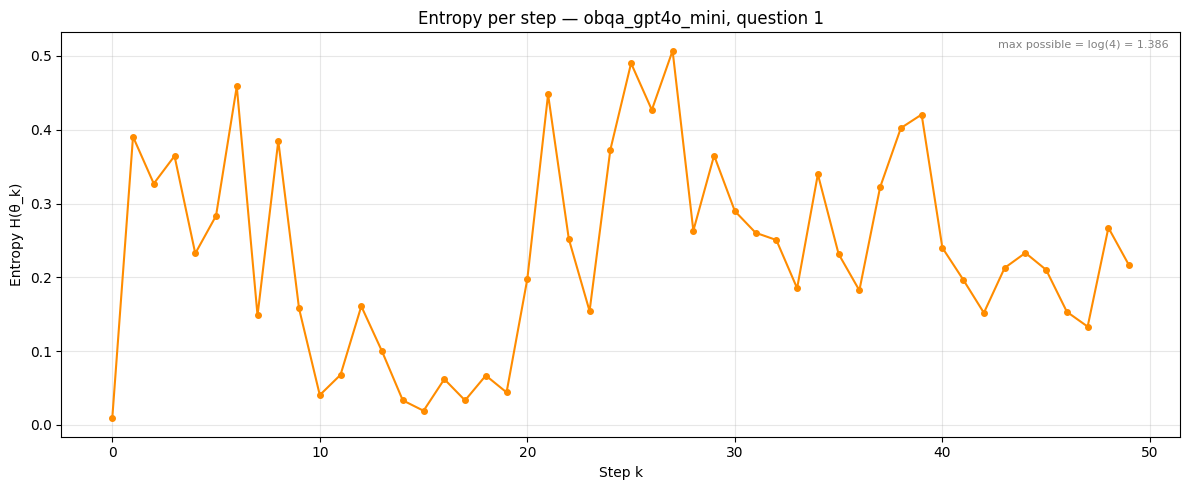

In [35]:
entropy_per_step = entropy_assessment(p_all, DATASET_KEY)

In [ ]:
## Mean Residuals per Class
res = dat["residuals"]

# assuming shape (Q, R, T, C)
mean_residual_per_class = res.mean(axis=(0, 1, 2))
std_residual_per_class = res.std(axis=(0, 1, 2))

print(mean_residual_per_class)

[ 3.82271451e-06 -1.21116922e-03 -3.64593671e-04  1.57194018e-03]


In [91]:
## Bootstrap Confidence Intervals for Mean Residuals

# residuals[q, r, t, c]: local martingale residual for class c at
# step t of one complete question/replication trajectory.
res = np.asarray(dat["residuals"], dtype=np.float64)  # (Q, R, T-1, C)
Q, R, T_minus_1, C = res.shape

# Collapse the serially dependent time points *within* each trajectory.
# Each row below is now one independent resampling unit; individual steps
# are never drawn separately by the bootstrap.
trajectory_mean_residual = res.mean(axis=2).reshape(Q * R, C)
n_trajectories = trajectory_mean_residual.shape[0]

n_bootstrap = 10_000
bootstrap_rng = np.random.default_rng(42)
trajectory_indices = bootstrap_rng.integers(
    0, n_trajectories, size=(n_bootstrap, n_trajectories)
)

# Resample whole trajectories with replacement and calculate the overall
# mean residual of every class for each bootstrap sample.
bootstrap_means = trajectory_mean_residual[trajectory_indices].mean(axis=1)
mean_residual_per_class = trajectory_mean_residual.mean(axis=0)
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975], axis=0)
zero_in_ci = (ci_low <= 0.0) & (ci_high >= 0.0)

metadata = dat.get("metadata", {})
class_labels = metadata.get("label_chars", list(range(C)))
bootstrap_ci = pd.DataFrame({
    "class": class_labels,
    "mean_residual": mean_residual_per_class,
    "ci_2.5%": ci_low,
    "ci_97.5%": ci_high,
    "zero_in_95%_ci": zero_in_ci,
    "direction_if_excluded": np.where(
        ci_low > 0.0, "positive", np.where(ci_high < 0.0, "negative", "--")
    ),
})

print(f"Bootstrap unit: complete trajectory (n={n_trajectories})")
bootstrap_ci_display = bootstrap_ci.copy()
for column in ["mean_residual", "ci_2.5%", "ci_97.5%"]:
    bootstrap_ci_display[column] = bootstrap_ci_display[column].map("{:+.6f}".format)
display(bootstrap_ci_display)

Bootstrap unit: complete trajectory (n=10)


,class,mean_residual,ci_2.5%,ci_97.5%,zero_in_95%_ci,direction_if_excluded
0,A,+0.000004,-0.000004,+0.000015,True,--
1,B,-0.001211,-0.003508,+0.000437,True,--
2,C,-0.000365,-0.001237,+0.000507,True,--
3,D,+0.001572,-0.000603,+0.004424,True,--


In [92]:
## ttest for mean residuals per class
from scipy.stats import ttest_1samp
trajectory_mean_residual = res.mean(axis=2)

for c in range(trajectory_mean_residual.shape[-1]):
    vals = trajectory_mean_residual[..., c].ravel()
    stat, p = ttest_1samp(vals, 0.0)
    print(c, vals.mean(), p)

0 3.822714514680844e-06 0.46875561984352127
1 -0.0012111692220474195 0.2939050478607251
2 -0.00036459367103740356 0.4361042414167835
3 0.0015719401785701497 0.2868409951872159


In [ ]:
## Mean L2 martingale error per step with a ±1 SD band
error_l2 = np.asarray(dat["error_l2"], dtype=np.float64)  # (Q, R, T-1)
mean_l2_by_step = error_l2.mean(axis=(0, 1))
std_l2_by_step = error_l2.std(axis=(0, 1))
steps = np.arange(len(mean_l2_by_step))

# L2 error is non-negative, so do not draw the lower SD band below zero.
lower_band = np.maximum(0.0, mean_l2_by_step - std_l2_by_step)
upper_band = mean_l2_by_step + std_l2_by_step

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(steps, mean_l2_by_step, color="steelblue", linewidth=2, label="Mean L2 error")
ax.fill_between(
    steps, lower_band, upper_band,
    color="steelblue", alpha=0.25, label="Mean ± 1 SD"
)
ax.set_xlabel("Step t")
ax.set_ylabel("L2 martingale error")
ax.set_title(f"Mean L2 martingale error by step — {DATASET_KEY}")
ax.set_xlim(steps[0], steps[-1])
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

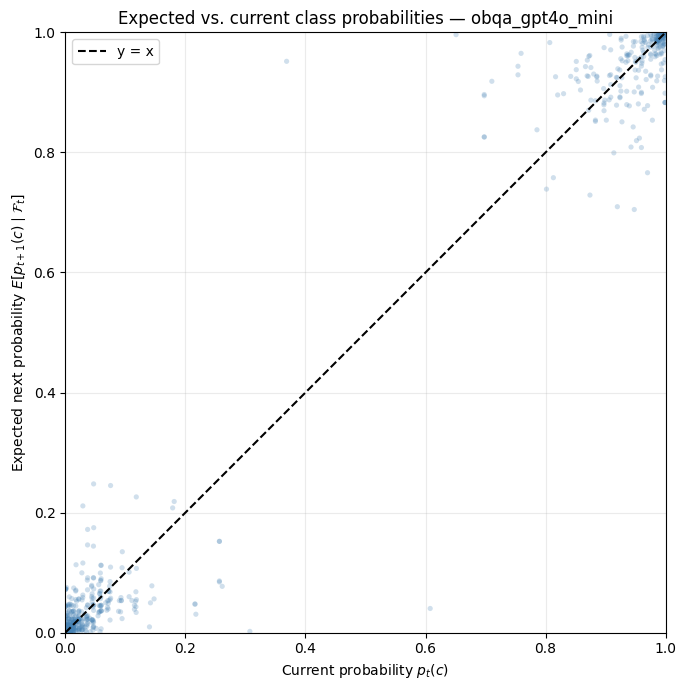

In [ ]:
## Expected next probabilities versus current probabilities
p = np.asarray(dat["probs"], dtype=np.float64)
e = np.asarray(dat["expected_next"], dtype=np.float64)

# expected_next has T-1 steps, so compare it with p_t at the same
# non-final steps. Flattening includes every question, trajectory, step,
# and class as one point in the scatter plot.
x = p[..., :-1, :].ravel()
y = e.ravel()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x, y, s=14, alpha=0.25, color="steelblue", edgecolors="none")

# Perfect local martingale consistency lies on this diagonal.
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="y = x")
ax.set_xlabel(r"Current probability $p_t(c)$")
ax.set_ylabel(r"Expected next probability $E[p_{t+1}(c) \mid \mathcal{F}_t]$")
ax.set_title(f"Expected vs. current class probabilities — {DATASET_KEY}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Not sure about this one yet

In [ ]:
## Regression of residuals on state variables
## There are lots of candidates : 8. bulletpoint on chatgpt answer. Look at it 

In [ ]:
## Compare correct vs incorrect states
## It may be that martingale violations are especially large when the model is confidently wrong.
## Similarly entropy residual correlation can be examined. Low entropy high residual correlation etc.
## Generally look at the ideas chatgpt provided and try to implemetn them.